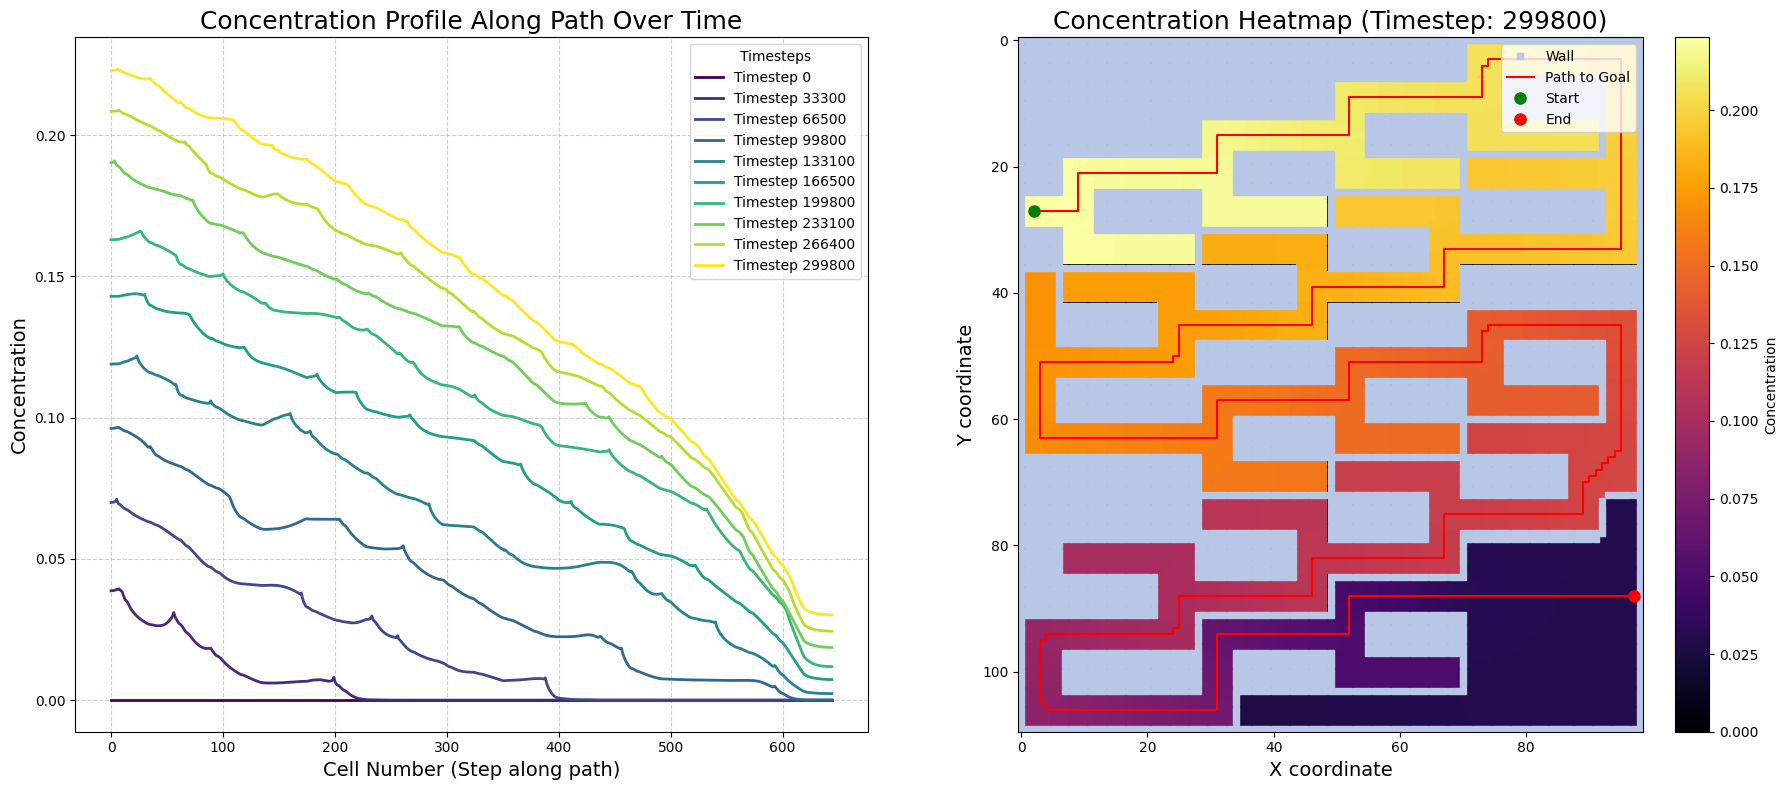

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sys
import os
import glob
import re

# --- 1. Path Extraction and Ordering ---
def extract_and_order_path(maze_array):
    # Find all coordinates where the maze is marked as 2 (the path)
    y_coords, x_coords = np.where(maze_array == 2)
    path_set = set(zip(y_coords, x_coords))
    
    if not path_set:
        raise ValueError("No path (value 2) found in the maze file.")

    def get_neighbors(r, c):
        directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]
        return [(r + dr, c + dc) for dr, dc in directions if (r + dr, c + dc) in path_set]

    endpoints = [node for node in path_set if len(get_neighbors(*node)) == 1]
    start_node = endpoints[0] if endpoints else list(path_set)[0]

    ordered_path = [start_node]
    visited = {start_node}
    current = start_node

    while len(visited) < len(path_set):
        neighbors = get_neighbors(*current)
        unvisited = [n for n in neighbors if n not in visited]
        
        if not unvisited:
            break 
            
        current = unvisited[0]
        ordered_path.append(current)
        visited.add(current)

    return ordered_path

# --- 2. Data Loading & Mapping ---
maze_file = "../different_mazes/Ran_maze_size_prop_to_droplet_testrun_copy.tsv"
try:
    maze = np.loadtxt(maze_file, delimiter='\t')
except OSError:
    print(f"Could not find {maze_file}. Using dummy maze.")
    maze = np.zeros((20, 20))
    maze[5:15, 5] = 2; maze[0:20, 0] = 1; maze[0:20, -1] = 1 

path_coords = extract_and_order_path(maze)

# Find and sort all concentration files
data_dir = "/home/ecasual/Documents/Uni/training-projects/Automated-decision-making-by-chemical-echolocation-in-active-droplets/data"
all_files = glob.glob(os.path.join(data_dir, "conc_*.txt"))

# Helper to extract the timestep integer from the filename (e.g., "100" from "conc_100.txt")
def get_timestep(filepath):
    match = re.search(r'conc_(\d+)\.txt', os.path.basename(filepath))
    return int(match.group(1)) if match else -1

# Filter out any weird files and sort them strictly numerically
valid_files = [f for f in all_files if get_timestep(f) >= 0]
valid_files.sort(key=get_timestep)

# Select 10 evenly spaced files
num_curves = 10
if len(valid_files) > 0:
    indices = np.linspace(0, len(valid_files) - 1, min(num_curves, len(valid_files)), dtype=int)
    selected_files = [valid_files[i] for i in indices]
else:
    selected_files = []
    print(f"No files matching conc_*.txt found in {data_dir}")

# Load data for all selected files
path_data_over_time = {}
last_conc_2d = np.zeros_like(maze, dtype=float) # Fallback / placeholder for heatmap

for file_path in selected_files:
    ts = get_timestep(file_path)
    try:
        conc_1d = np.loadtxt(file_path, skiprows=3).flatten()
        if conc_1d.size == maze.size:
            conc_2d = conc_1d.reshape(maze.shape, order='F')
            
            # ---> USE THE FLIP THAT WORKED FOR YOU HERE <---
            conc_2d = np.flipud(conc_2d) # or np.flipud(conc_2d)
            
            # Extract values along the path
            path_concentrations = [conc_2d[r, c] for r, c in path_coords]
            path_data_over_time[ts] = path_concentrations
            
            # Save the last successful 2D map to display in the heatmap
            last_conc_2d = conc_2d
            
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# --- 3. Plotting ---
plt.style.use("default")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: 1D Concentration Profile (Multiple Curves)
ax1.set_title("Concentration Profile Along Path Over Time", fontsize=18)
ax1.set_xlabel("Cell Number (Step along path)", fontsize=14)
ax1.set_ylabel("Concentration", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)

# Generate a sequence of colors from the 'viridis' colormap
colors = cm.viridis(np.linspace(0, 1, len(path_data_over_time)))

for (ts, path_conc), color in zip(path_data_over_time.items(), colors):
    ax1.plot(range(len(path_conc)), path_conc, color=color, linewidth=2, label=f"Timestep {ts}")

if path_data_over_time:
    ax1.legend(loc="upper right", fontsize=10, title="Timesteps")

# Subplot 2: 2D Heatmap (Showing the last evaluated timestep)
heatmap = ax2.imshow(last_conc_2d, cmap='inferno', alpha=1.0)
fig.colorbar(heatmap, ax=ax2, fraction=0.046, pad=0.04, label="Concentration")

# Overlay walls
wall_y, wall_x = np.where(maze == 1)
ax2.plot(wall_x, wall_y, "s", markersize=4, color="#B8C7E5", label="Wall")

# Overlay path
path_x = [c for r, c in path_coords]
path_y = [r for r, c in path_coords]
ax2.plot(path_x, path_y, color='red', linewidth=1.5, label="Path to Goal")

ax2.plot(path_x[0], path_y[0], 'go', markersize=8, label="Start")
ax2.plot(path_x[-1], path_y[-1], 'ro', markersize=8, label="End")

# Update title to reflect which timestep is shown
final_ts = list(path_data_over_time.keys())[-1] if path_data_over_time else "Unknown"
ax2.set_title(f"Concentration Heatmap (Timestep: {final_ts})", fontsize=18)
ax2.set_xlabel("X coordinate", fontsize=14)
ax2.set_ylabel("Y coordinate", fontsize=14)
ax2.set_aspect("equal")
ax2.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()